# Special ensembles on hard datasets

In notebook 02 the special (resampling) ensembles -- RUSBoost, EasyEnsemble
and BalancedRandomForest -- were **not** better than ordinary ensembles
(CatBoost, XGBoost, LightGBM, random forests). A natural objection is that
those datasets are well separated: when a plain ensemble already discriminates
the classes well, there is little room for resampling to help.

This notebook re-runs the comparison on three datasets chosen because standard
ensembles do **poorly** on them (no single feature separates the classes and
the best ensemble reaches only a modest ROC-AUC), while keeping everything else
identical to notebook 02: same models, same successive-halving tuning, same
optimal-threshold evaluation. See `docs/hard_datasets.md` for provenance and
licenses (all three are CC BY 4.0).


In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import os
import pickle
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from functions.hard_data import DATASETS_HARD, load_hard_dataset
from functions.analysis import create_df
from functions.plotting import compute_ylim

warnings.filterwarnings('ignore', message='X does not have valid feature names')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)
datasets = DATASETS_HARD
datasets

['diabetes130', 'default_credit', 'secom']

## Load results

Merge the standard-ensemble and special-ensemble results (produced by the
`*-hard` training and evaluation scripts) into a single dictionary per dataset.

In [3]:
with open('../models/ensembles-hard/results', 'rb') as f:
    classic_dict = pickle.load(f)

with open('../models/special-ensembles-hard/results', 'rb') as f:
    special_dict = pickle.load(f)

scores_dict = {
    key: {**classic_dict[key], **special_dict[key]}
    for key in classic_dict
}

In [4]:
standard_models = ['rf', 'ada', 'gbm', 'cat', 'lgbm', 'xgb']
special_models = ['rusboost', 'easyEnsemble', 'balancedRF']
models = standard_models + special_models

## These datasets are hard

For each dataset we report the strongest single feature (the maximum univariate
ROC-AUC, taken as `max(auc, 1 - auc)` over all features -- the screen from
`datasets-with-perfect-separation.ipynb`) and the best standard ensemble's test
ROC-AUC. A dataset is *hard* when no single feature separates the classes
(max univariate AUC well below 0.90) and even the best tuned ensemble only
reaches a modest ROC-AUC.

In [5]:
rows = []
for ds in datasets:
    X_train, X_test, y_train, y_test = load_hard_dataset(ds)
    uni = max(
        max(roc_auc_score(y_train, X_train.iloc[:, j]),
            1 - roc_auc_score(y_train, X_train.iloc[:, j]))
        for j in range(X_train.shape[1])
    )
    best_std = max(scores_dict[ds][m][0] for m in standard_models)  # roc is column 0
    rows.append({
        'dataset': ds,
        'positive_rate': round(float(y_train.mean()), 3),
        'n_features': X_train.shape[1],
        'max_univariate_auc': round(float(uni), 3),
        'best_standard_roc': round(float(best_std), 3),
    })
hardness = pd.DataFrame(rows).set_index('dataset')
hardness

,positive_rate,n_features,max_univariate_auc,best_standard_roc
dataset,,,,
diabetes130,0.111,45,0.607,0.678
default_credit,0.224,23,0.687,0.784
secom,0.071,474,0.697,0.792


In [6]:
# sanity check: one full metrics table
create_df(scores_dict, datasets[0], models)

,roc,roc_std,ap,ap_std,precision,precision_std,recall,recall_std,f1_score,f1_std,mcc,mcc_std,ba,ba_std,brier,brier_std,gmean,gmean_std,thresh,tresh_std
rf,0.673278,0.006108,0.222598,0.006295,0.215332,0.013315,0.431583,0.023457,0.286666,0.010040,0.177106,0.011439,0.627956,0.006233,0.093977,0.002624,0.626051,0.005825,0.143505,0.010195
ada,0.661752,0.006200,0.204248,0.008292,0.206848,0.018911,0.424977,0.053969,0.275537,0.009987,0.164028,0.011585,0.621433,0.006442,0.145546,0.001160,0.620943,0.006642,0.353641,0.007195
gbm,0.672230,0.006459,0.213784,0.009019,0.200177,0.013211,0.493058,0.042579,0.283472,0.008371,0.173032,0.007877,0.628641,0.004816,0.094839,0.002566,0.626012,0.005533,0.132136,0.010444
cat,0.661710,0.004982,0.212349,0.008296,0.203129,0.011178,0.461097,0.016543,0.281754,0.011279,0.171721,0.009441,0.621681,0.006635,0.095369,0.002601,0.617983,0.005879,0.136583,0.004428
lgbm,0.668508,0.006714,0.213902,0.008215,0.190995,0.008155,0.535009,0.037479,0.281119,0.009890,0.171884,0.009252,0.629164,0.005485,0.094834,0.002491,0.628020,0.005376,0.123994,0.006014
xgb,0.677985,0.006822,0.224476,0.006319,0.203994,0.021013,0.512262,0.078472,0.287760,0.009210,0.182230,0.009778,0.635633,0.008499,0.093848,0.002612,0.634422,0.008967,0.131173,0.013173
rusboost,0.660720,0.009102,0.215741,0.006589,0.208420,0.011026,0.404339,0.039905,0.274215,0.012106,0.167486,0.011406,0.614735,0.007306,0.240820,0.001256,0.613069,0.007693,0.601120,0.014807
easyEnsemble,0.631215,0.007365,0.171159,0.007313,0.180762,0.015450,0.439410,0.050336,0.254191,0.009874,0.133527,0.012849,0.596876,0.006112,0.227836,0.001666,0.585485,0.003623,0.591838,0.046930
balancedRF,0.671791,0.005713,0.215308,0.005510,0.207014,0.015718,0.469561,0.039664,0.285857,0.010168,0.176196,0.009190,0.628835,0.004708,0.226843,0.000865,0.628415,0.005058,0.554432,0.014004


## Predicted probability distributions

Before comparing metrics, check the special ensembles produce well-spread
probabilities (a degenerate, near-constant distribution would make any
threshold-based metric meaningless).

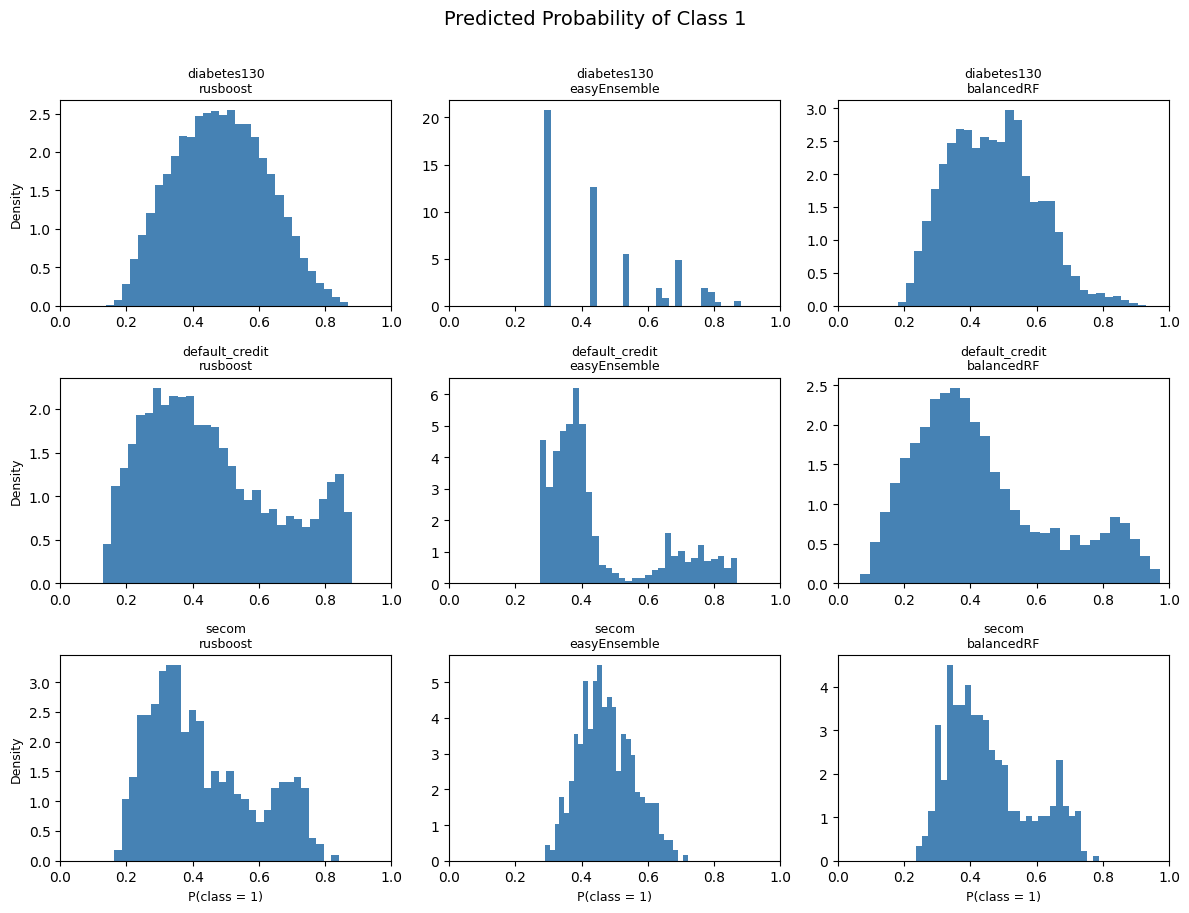

In [7]:
fig, axes = plt.subplots(len(datasets), len(special_models),
                         figsize=(4 * len(special_models), 3 * len(datasets)))
MODELS_DIR = '../models/special-ensembles-hard'
for i, dataset in enumerate(datasets):
    _, X_test, _, y_test = load_hard_dataset(dataset)
    for j, estimator in enumerate(special_models):
        search = joblib.load(f'{MODELS_DIR}/{dataset}_{estimator}.pkl')
        probs = search.predict_proba(X_test)[:, 1]
        ax = axes[i, j]
        ax.hist(probs, bins=30, density=True, color='steelblue')
        ax.set_xlim(0, 1)
        ax.set_title(f'{dataset}\n{estimator}', fontsize=9)
        if j == 0:
            ax.set_ylabel('Density', fontsize=9)
        if i == len(datasets) - 1:
            ax.set_xlabel('P(class = 1)', fontsize=9)
plt.suptitle('Predicted Probability of Class 1', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/special-ensembles-hard_prob_dist.png', dpi=200, bbox_inches='tight')
plt.show()

## Performance per metric

Each panel is one dataset; points are the nine models (mean +/- std over the
bootstrap test samples). The pink band is the random forest's error bar -- the
same reference used in notebook 02. A special ensemble 'wins' only if it sits
clearly **above** the standard ensembles (for Brier, below). All threshold-based
metrics are taken at their optimal threshold.

In [8]:
def plot_metric(metric, std_metric, title, fname):
    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5))
    if len(datasets) == 1:
        axes = [axes]
    for ax, data in zip(axes, datasets):
        df = create_df(scores_dict, data, models)
        means = df[metric]
        stds = df[std_metric]
        upper = df.loc['rf', metric] + df.loc['rf', std_metric]
        lower = df.loc['rf', metric] - df.loc['rf', std_metric]
        colors = ['tab:blue'] * len(standard_models) + ['tab:red'] * len(special_models)
        ax.errorbar(x=df.index, y=means, yerr=stds, fmt='none', ecolor='gray', capsize=5, zorder=1)
        ax.scatter(df.index, means, c=colors, s=80, zorder=2)
        ax.set_title(data, fontsize=14)
        ax.set_ylim(compute_ylim(means, stds, upper, lower))
        ax.tick_params(axis='x', rotation=90)
        ax.grid(True, alpha=0.3)
        ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
        ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
        ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)
    plt.suptitle(title, fontsize=15, y=1.03)
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()

# blue = standard ensembles, red = special (resampling) ensembles; pink band = RF +/- std

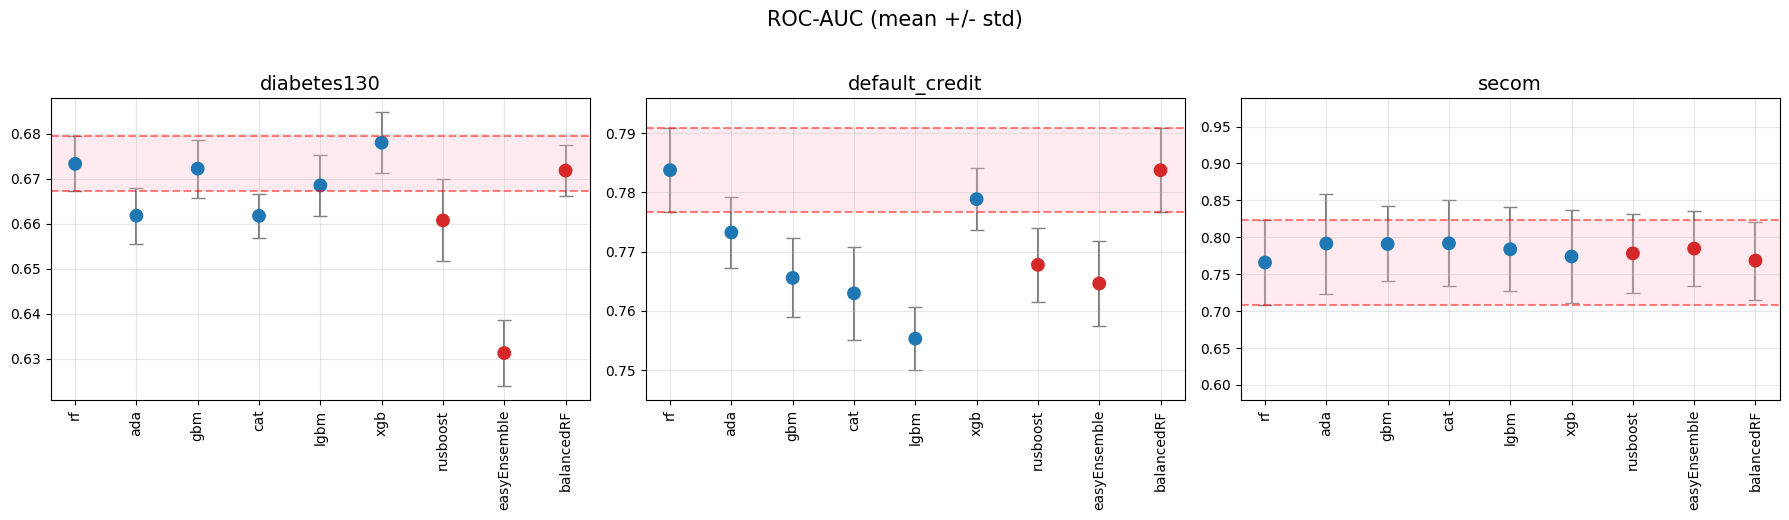

In [9]:
plot_metric('roc', 'roc_std', 'ROC-AUC (mean +/- std)', '../figures/special-ensembles-hard_rocauc.png')

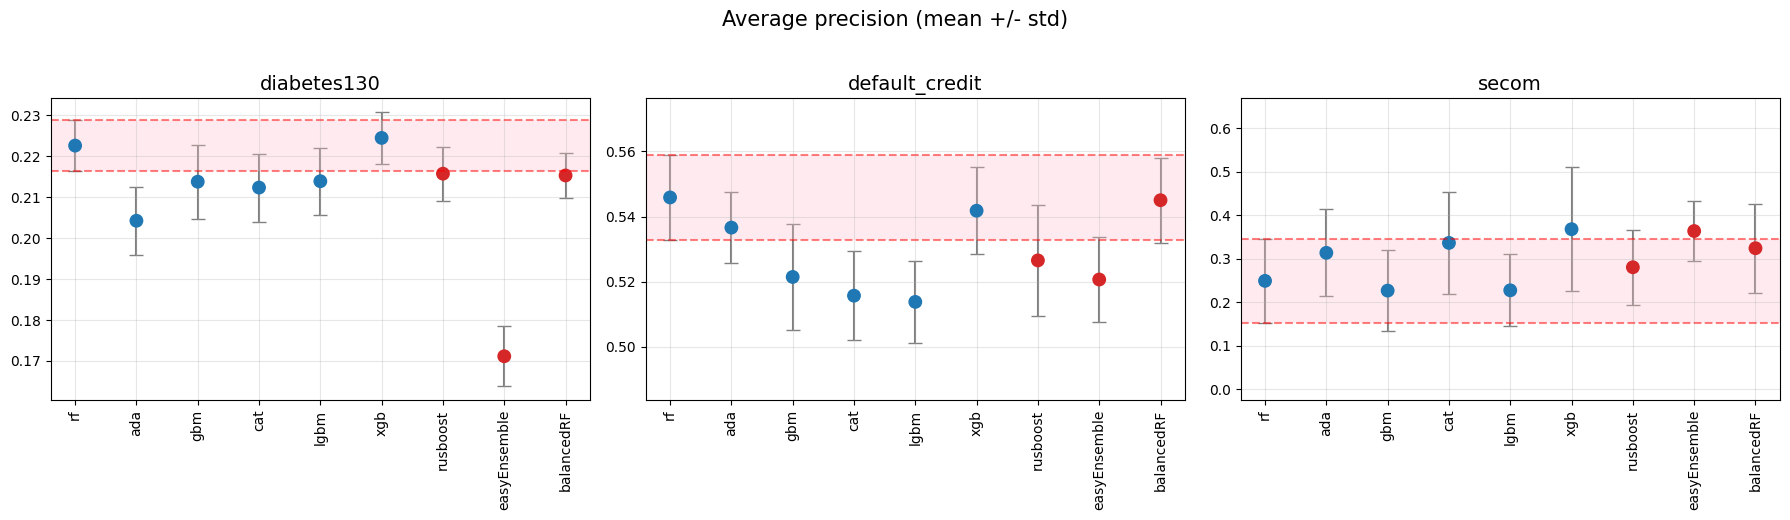

In [10]:
plot_metric('ap', 'ap_std', 'Average precision (mean +/- std)', '../figures/special-ensembles-hard_ap.png')

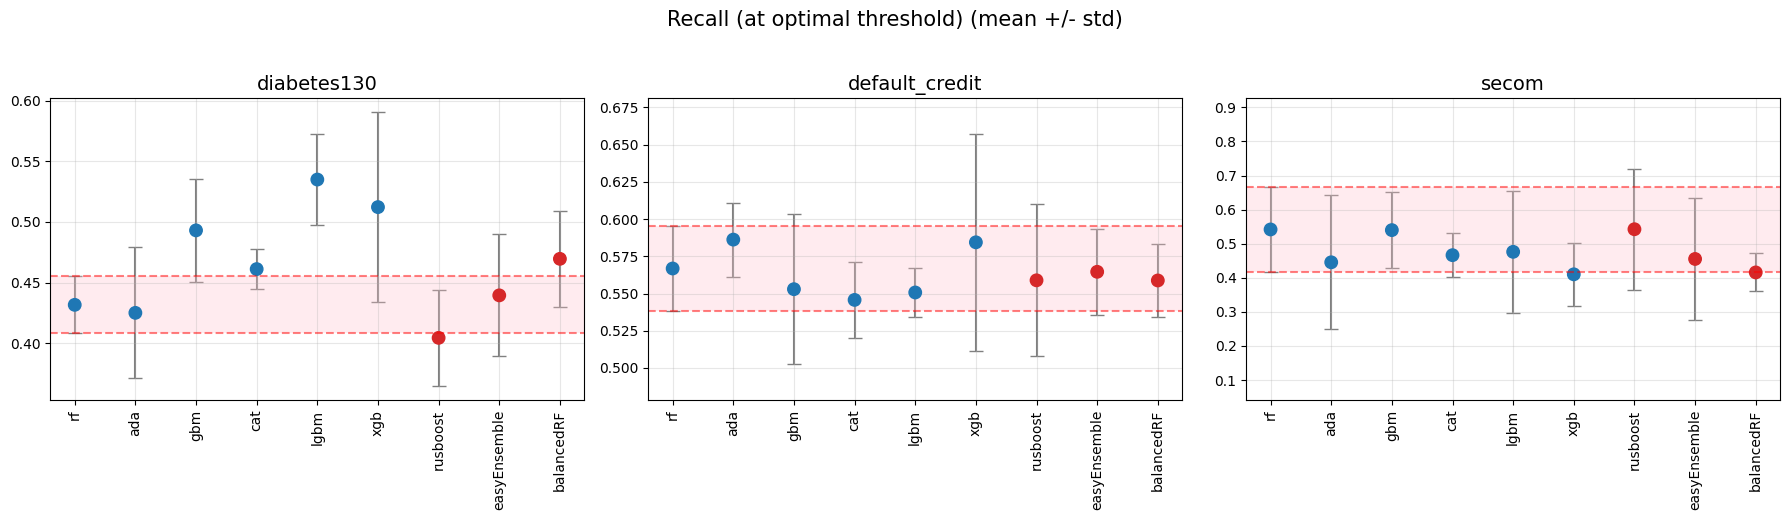

In [11]:
plot_metric('recall', 'recall_std', 'Recall (at optimal threshold) (mean +/- std)', '../figures/special-ensembles-hard_recall.png')

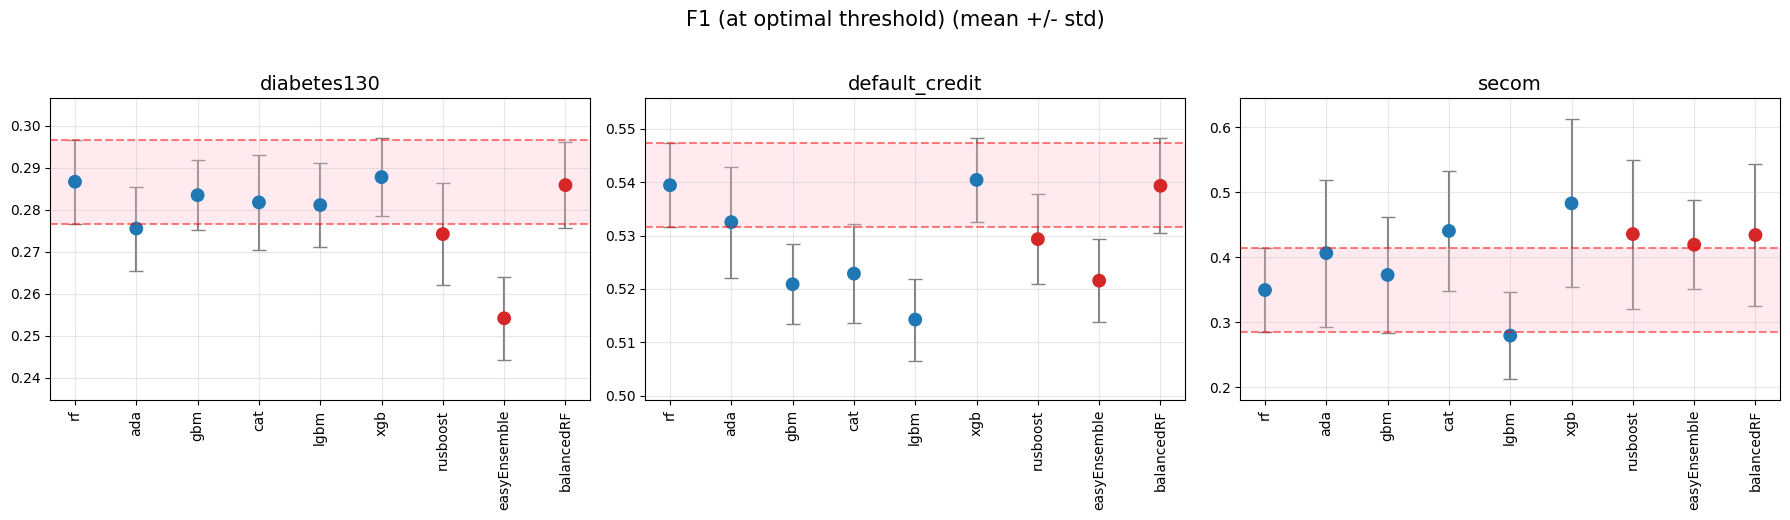

In [12]:
plot_metric('f1_score', 'f1_std', 'F1 (at optimal threshold) (mean +/- std)', '../figures/special-ensembles-hard_f1.png')

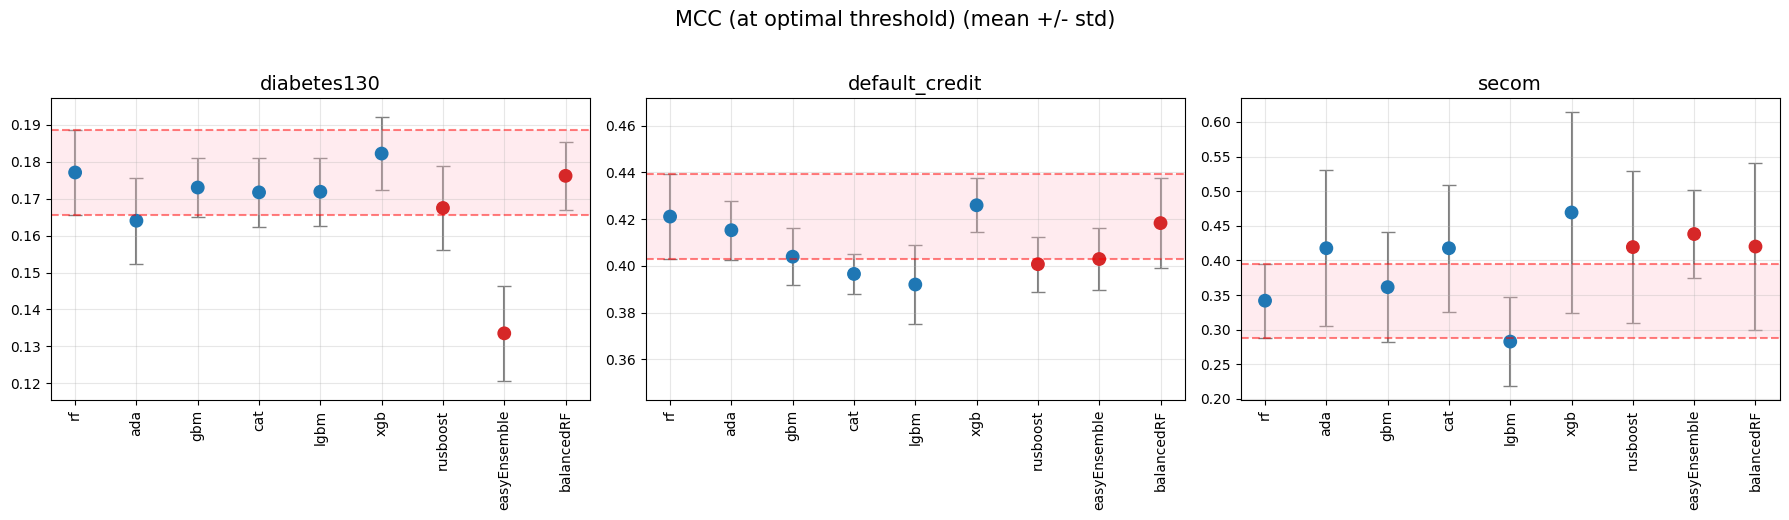

In [13]:
plot_metric('mcc', 'mcc_std', 'MCC (at optimal threshold) (mean +/- std)', '../figures/special-ensembles-hard_mcc.png')

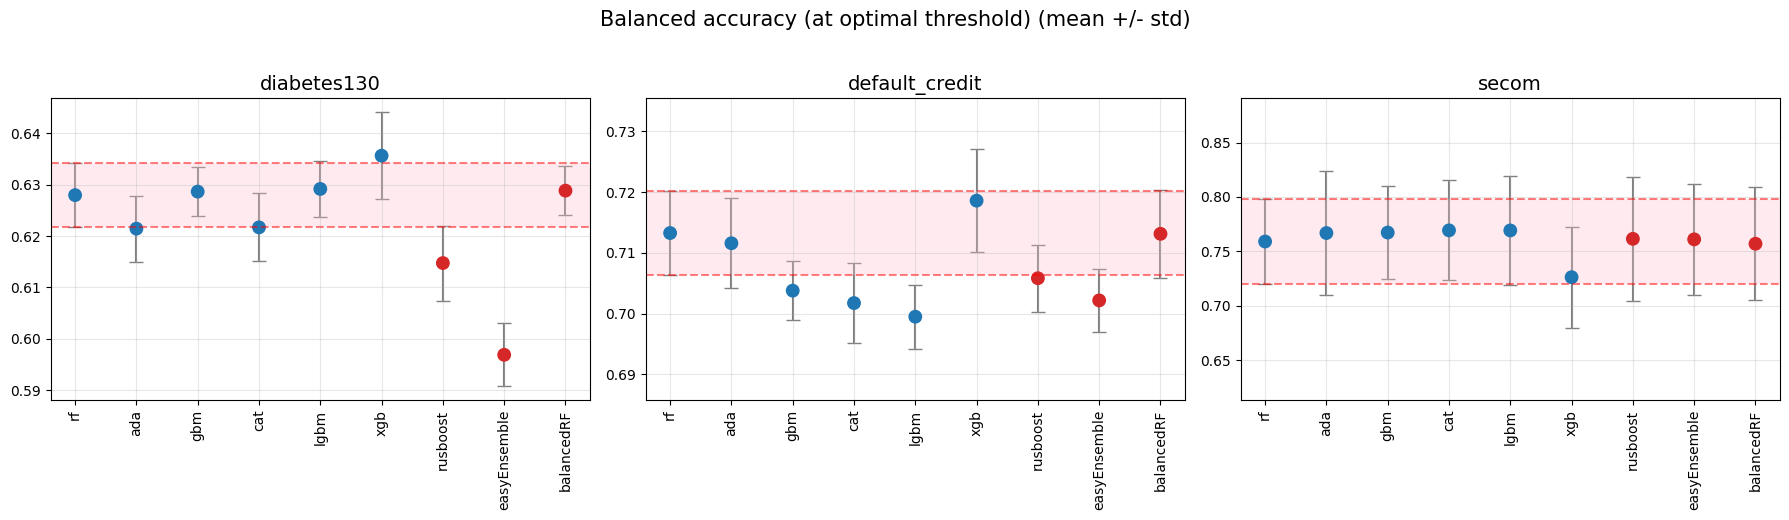

In [14]:
plot_metric('ba', 'ba_std', 'Balanced accuracy (at optimal threshold) (mean +/- std)', '../figures/special-ensembles-hard_ba.png')

## Combined table

In [15]:
dfs = [create_df(scores_dict, data, models) for data in datasets]
result = pd.concat(dfs, keys=datasets, names=['dataset', 'model'])
for col, std in [('roc', 'roc_std'), ('ap', 'ap_std'), ('f1_score', 'f1_std'),
                 ('mcc', 'mcc_std'), ('ba', 'ba_std'), ('gmean', 'gmean_std')]:
    result[f'{col}_pm'] = (result[col].round(3).astype(str) + ' +/- '
                            + result[std].round(3).astype(str))
result.to_csv('../results/special-ensembles-hard_models_performance.csv')
result[['roc_pm', 'ap_pm', 'f1_score_pm', 'mcc_pm', 'ba_pm', 'gmean_pm']]

roc_pm            ap_pm  \
dataset        model                                            
diabetes130    rf            0.673 +/- 0.006  0.223 +/- 0.006   
               ada           0.662 +/- 0.006  0.204 +/- 0.008   
               gbm           0.672 +/- 0.006  0.214 +/- 0.009   
               cat           0.662 +/- 0.005  0.212 +/- 0.008   
               lgbm          0.669 +/- 0.007  0.214 +/- 0.008   
               xgb           0.678 +/- 0.007  0.224 +/- 0.006   
               rusboost      0.661 +/- 0.009  0.216 +/- 0.007   
               easyEnsemble  0.631 +/- 0.007  0.171 +/- 0.007   
               balancedRF    0.672 +/- 0.006  0.215 +/- 0.006   
default_credit rf            0.784 +/- 0.007  0.546 +/- 0.013   
               ada           0.773 +/- 0.006  0.537 +/- 0.011   
               gbm           0.766 +/- 0.007  0.521 +/- 0.016   
               cat           0.763 +/- 0.008  0.516 +/- 0.014   
               lgbm          0.755 +/- 0.005  0.514 +/- 0.013   
               xgb           0.779 +/- 0.005  0.542 +/- 0.013   
               rusboost      0.768 +/- 0.006  0.527 +/- 0.017   
               easyEnsemble  0.765 +/- 0.007  0.521 +/- 0.013   
               balancedRF    0.784 +/- 0.007  0.545 +/- 0.013   
secom          rf            0.766 +/- 0.057  0.249 +/- 0.097   
               ada           0.792 +/- 0.068    0.313 +/- 0.1   
               gbm           0.791 +/- 0.051  0.227 +/- 0.093   
               cat           0.792 +/- 0.058  0.336 +/- 0.117   
               lgbm          0.784 +/- 0.057  0.227 +/- 0.083   
               xgb           0.774 +/- 0.062  0.368 +/- 0.143   
               rusboost      0.778 +/- 0.054   0.28 +/- 0.086   
               easyEnsemble  0.785 +/- 0.051  0.364 +/- 0.069   
               balancedRF    0.768 +/- 0.053  0.324 +/- 0.102   

                                 f1_score_pm           mcc_pm  \
dataset        model                                            
diabetes130    rf             0.287 +/- 0.01  0.177 +/- 0.011   
               ada            0.276 +/- 0.01  0.164 +/- 0.012   
               gbm           0.283 +/- 0.008  0.173 +/- 0.008   
               cat           0.282 +/- 0.011  0.172 +/- 0.009   
               lgbm           0.281 +/- 0.01  0.172 +/- 0.009   
               xgb           0.288 +/- 0.009   0.182 +/- 0.01   
               rusboost      0.274 +/- 0.012  0.167 +/- 0.011   
               easyEnsemble   0.254 +/- 0.01  0.134 +/- 0.013   
               balancedRF     0.286 +/- 0.01  0.176 +/- 0.009   
default_credit rf            0.539 +/- 0.008  0.421 +/- 0.018   
               ada            0.533 +/- 0.01  0.415 +/- 0.013   
               gbm           0.521 +/- 0.007  0.404 +/- 0.012   
               cat           0.523 +/- 0.009  0.397 +/- 0.009   
               lgbm          0.514 +/- 0.008  0.392 +/- 0.017   
               xgb            0.54 +/- 0.008  0.426 +/- 0.012   
               rusboost      0.529 +/- 0.008  0.401 +/- 0.012   
               easyEnsemble  0.522 +/- 0.008  0.403 +/- 0.013   
               balancedRF    0.539 +/- 0.009  0.418 +/- 0.019   
secom          rf            0.349 +/- 0.065  0.342 +/- 0.053   
               ada           0.406 +/- 0.113  0.418 +/- 0.113   
               gbm           0.373 +/- 0.089   0.361 +/- 0.08   
               cat            0.44 +/- 0.092  0.418 +/- 0.092   
               lgbm          0.279 +/- 0.067  0.283 +/- 0.064   
               xgb           0.483 +/- 0.129  0.469 +/- 0.145   
               rusboost      0.435 +/- 0.114  0.419 +/- 0.109   
               easyEnsemble  0.419 +/- 0.068  0.438 +/- 0.064   
               balancedRF     0.434 +/- 0.11    0.42 +/- 0.12   

                                       ba_pm         gmean_pm  
dataset        model                                           
diabetes130    rf            0.628 +/- 0.006  0.626 +/- 0.006  
               ada           0.621 +/- 0.006  0.621 +/- 0.007  
          

## Do special ensembles win where standard ensembles struggle?

For each dataset and metric, compare the **best** special ensemble against the
**best** standard ensemble. A positive delta means resampling helped. We focus
on the metrics that matter under imbalance: average precision and ROC-AUC
(threshold-free) and F1, MCC, balanced accuracy and G-mean at the optimal
threshold.

In [16]:
metric_cols = {'roc': 'roc', 'ap': 'ap', 'f1': 'f1_score', 'mcc': 'mcc',
               'ba': 'ba', 'gmean': 'gmean'}
summary = []
for ds in datasets:
    df = create_df(scores_dict, ds, models)
    for short, col in metric_cols.items():
        best_std = df.loc[standard_models, col].max()
        best_spc = df.loc[special_models, col].max()
        best_std_model = df.loc[standard_models, col].idxmax()
        best_spc_model = df.loc[special_models, col].idxmax()
        summary.append({
            'dataset': ds, 'metric': short,
            'best_standard': round(float(best_std), 3), 'std_model': best_std_model,
            'best_special': round(float(best_spc), 3), 'special_model': best_spc_model,
            'delta_special_minus_standard': round(float(best_spc - best_std), 3),
        })
summary = pd.DataFrame(summary)
summary

,dataset,metric,best_standard,std_model,best_special,special_model,delta_special_minus_standard
0,diabetes130,roc,0.678,xgb,0.672,balancedRF,-0.006
1,diabetes130,ap,0.224,xgb,0.216,rusboost,-0.009
2,diabetes130,f1,0.288,xgb,0.286,balancedRF,-0.002
3,diabetes130,mcc,0.182,xgb,0.176,balancedRF,-0.006
4,diabetes130,ba,0.636,xgb,0.629,balancedRF,-0.007
5,diabetes130,gmean,0.634,xgb,0.628,balancedRF,-0.006
6,default_credit,roc,0.784,rf,0.784,balancedRF,-0.000
7,default_credit,ap,0.546,rf,0.545,balancedRF,-0.001
8,default_credit,f1,0.540,xgb,0.539,balancedRF,-0.001
9,default_credit,mcc,0.426,xgb,0.418,balancedRF,-0.008


In [17]:
# Verdict: in how many (dataset, metric) cells did the best special ensemble beat
# the best standard ensemble, and by how much on average?
wins = (summary['delta_special_minus_standard'] > 0).sum()
total = len(summary)
print(f'Special ensemble beats best standard ensemble in {wins}/{total} (dataset, metric) cells')
print(f'Mean delta (best special - best standard): {summary.delta_special_minus_standard.mean():+.3f}')
print()
pivot = summary.pivot(index='dataset', columns='metric', values='delta_special_minus_standard')
pivot = pivot[['roc', 'ap', 'f1', 'mcc', 'ba', 'gmean']]
print('Delta (best special - best standard) per dataset and metric:')
pivot

Special ensemble beats best standard ensemble in 0/18 (dataset, metric) cells
Mean delta (best special - best standard): -0.009

Delta (best special - best standard) per dataset and metric:


metric,roc,ap,f1,mcc,ba,gmean
dataset,,,,,,
default_credit,-0.000,-0.001,-0.001,-0.008,-0.005,-0.008
diabetes130,-0.006,-0.009,-0.002,-0.006,-0.007,-0.006
secom,-0.007,-0.004,-0.047,-0.031,-0.008,-0.002


## Conclusion

**Special ensembles did not beat standard ensembles, even on datasets where
standard ensembles do poorly.** Across the three hard datasets and six metrics
(18 dataset-metric comparisons), the best special ensemble (RUSBoost,
EasyEnsemble or BalancedRandomForest) never exceeded the best standard ensemble
(random forest, AdaBoost, GBM, CatBoost, LightGBM, XGBoost). The mean gap was
about -0.009 in favour of the standard ensembles.

- On **diabetes130** and **default_credit** the two families are effectively
  tied (differences within ~0.01 on every metric): resampling neither helps nor
  hurts.
- On **secom** the standard ensembles are clearly ahead on the optimal-threshold
  metrics (XGBoost F1 0.48 vs 0.44, MCC 0.47 vs 0.44).
- Among the special ensembles, **BalancedRandomForest** is the most competitive
  (it matches the random forest on ROC-AUC and average precision); EasyEnsemble
  is the weakest. **XGBoost** is the strongest single model, best on diabetes130
  and secom.

This extends the notebook-02 finding into the regime it was missing. These
datasets are hard not because of imbalance alone but because the features
**overlap the classes** (max univariate AUC 0.61-0.70; best ensemble ROC
0.67-0.79). Resampling rebalances the classes; it does not create signal that is
not there. So where 'hard' means 'weak features', the special ensembles have
nothing extra to exploit and -- evaluated at the optimal threshold -- do not
improve over ordinary ensembles.

**Caveat.** All three datasets are hard because of class overlap. A different
kind of hard dataset -- strong per-class signal but extreme imbalance with a
tiny absolute minority -- could still favour resampling; that regime is not
represented here and is worth testing separately.
